In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_excel("Online_Retail.xlsx")

print("Original shape:", df.shape)
display(df.head())
print("\nInfo:")
print(df.info())
print("\nDescribe (numeric columns):")
display(df.describe())
print("\nNull value counts:")
display(df.isnull().sum())

Original shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

Describe (numeric columns):


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



Null value counts:


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [5]:
df = df.dropna(subset=["Description", "CustomerID"])
print("Shape after dropping nulls:", df.shape)

df["CustomerID"] = df["CustomerID"].astype(str)

if not np.issubdtype(df["InvoiceDate"].dtype, np.datetime64):
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

Shape after dropping nulls: (406829, 8)


In [6]:
df["Amount"] = df["Quantity"] * df["UnitPrice"]

df_m = (
    df.groupby("CustomerID", as_index=True)["Amount"]
      .sum()
      .reset_index()
      .rename(columns={"Amount": "Amount"})
)

print("Customer-level Monetary (Amount):")
display(df_m.head())

Customer-level Monetary (Amount):


,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [7]:
df_f = (
    df.groupby("CustomerID", as_index=True)["InvoiceNo"]
      .nunique()
      .reset_index()
      .rename(columns={"InvoiceNo": "Frequency"})
)

print("Customer-level Frequency:")
display(df_f.head())

Customer-level Frequency:


,CustomerID,Frequency
0,12346.0,2
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


In [8]:
max_date = df["InvoiceDate"].max()
print("Max InvoiceDate (last transaction date):", max_date)

df["Diff"] = max_date - df["InvoiceDate"]

df_r = (
    df.groupby("CustomerID", as_index=True)["Diff"]
      .min()
      .reset_index()
)
df_r["Recency"] = df_r["Diff"].dt.days
df_r = df_r[["CustomerID", "Recency"]]

print("Customer-level Recency (days):")
display(df_r.head())

Max InvoiceDate (last transaction date): 2011-12-09 12:50:00
Customer-level Recency (days):


,CustomerID,Recency
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [9]:
df_retail = (
    df_m.merge(df_f, on="CustomerID", how="inner")
        .merge(df_r, on="CustomerID", how="inner")
)

print("RFM dataframe shape:", df_retail.shape)
display(df_retail.head())

RFM dataframe shape: (4372, 4)


,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,7,1
2,12348.0,1797.24,4,74
3,12349.0,1757.55,1,18
4,12350.0,334.40,1,309


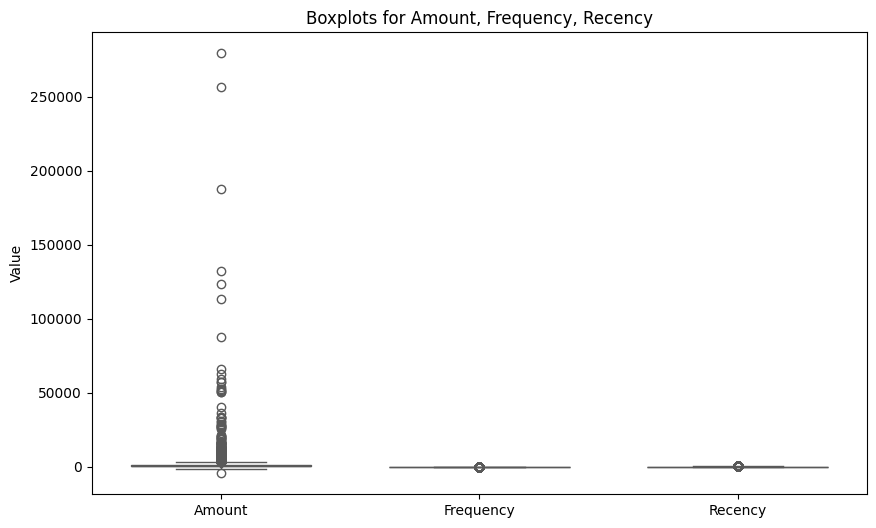

In [10]:
attrs = ["Amount", "Frequency", "Recency"]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_retail[attrs], orient="v", palette="Set2", width=0.7)
plt.title("Boxplots for Amount, Frequency, Recency")
plt.ylabel("Value")
plt.show()

In [11]:
def remove_outliers_iqr(data, col):
    q1 = data[col].quantile(0.05)
    q3 = data[col].quantile(0.95)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data[col] > lower) & (data[col] < upper)]

for col in ["Amount", "Frequency", "Recency"]:
    df_retail = remove_outliers_iqr(df_retail, col)

print("Shape after outlier removal:", df_retail.shape)
display(df_retail.describe())

Shape after outlier removal: (4294, 4)


,Amount,Frequency,Recency
count,4294.000000,4294.000000,4294.000000
mean,1264.767306,4.268281,92.477643
std,1729.705711,4.676015,100.947754
min,-4287.630000,1.000000,0.000000
25%,289.475000,1.000000,17.000000
50%,633.315000,3.000000,50.000000
75%,1519.860000,5.000000,144.000000
max,13677.590000,33.000000,373.000000


In [12]:
df_features = df_retail[["Amount", "Frequency", "Recency"]].copy()

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_features)

df_retail_scaled = pd.DataFrame(
    scaled_values,
    columns=["Amount", "Frequency", "Recency"],
    index=df_retail.index
)

print("Scaled features (head):")
display(df_retail_scaled.head())

Scaled features (head):


,Amount,Frequency,Recency
0,-0.731289,-0.485145,2.303661
1,1.760755,0.584266,-0.906294
2,0.307876,-0.057381,-0.183063
3,0.284927,-0.699027,-0.737870
4,-0.537939,-0.699027,2.145145


In [13]:
df_features = df_retail[["Amount", "Frequency", "Recency"]].copy()

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_features)

df_retail_scaled = pd.DataFrame(
    scaled_values,
    columns=["Amount", "Frequency", "Recency"],
    index=df_retail.index
)

print("Scaled features (head):")
display(df_retail_scaled.head())

Scaled features (head):


,Amount,Frequency,Recency
0,-0.731289,-0.485145,2.303661
1,1.760755,0.584266,-0.906294
2,0.307876,-0.057381,-0.183063
3,0.284927,-0.699027,-0.737870
4,-0.537939,-0.699027,2.145145


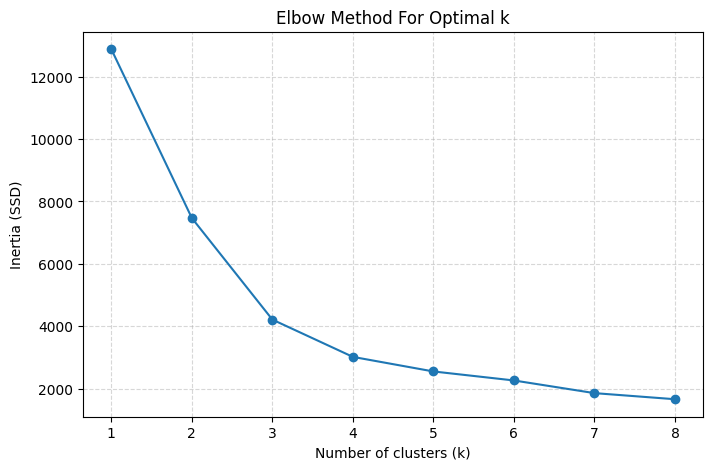

In [14]:
ssd = []
range_n_clusters = range(1, 9)

for n_clusters in range_n_clusters:
    km = KMeans(n_clusters=n_clusters, max_iter=50, random_state=42)
    km.fit(df_retail_scaled)
    ssd.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, ssd, marker="o")
plt.title("Elbow Method For Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSD)")
plt.xticks(range_n_clusters)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [15]:
k_final = 3
kmeans = KMeans(n_clusters=k_final, max_iter=50, random_state=42)
kmeans.fit(df_retail_scaled)

df_retail["Cluster"] = kmeans.labels_

print("Cluster counts:")
print(df_retail["Cluster"].value_counts())
display(df_retail.head())

Cluster counts:
Cluster
0    2750
2    1071
1     473
Name: count, dtype: int64


,CustomerID,Amount,Frequency,Recency,Cluster
0,12346.0,0.00,2,325,2
1,12347.0,4310.00,7,1,1
2,12348.0,1797.24,4,74,0
3,12349.0,1757.55,1,18,0
4,12350.0,334.40,1,309,2


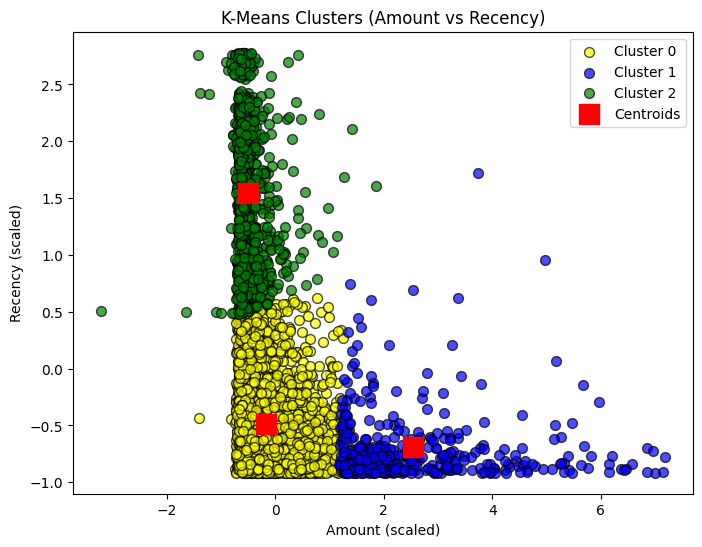

In [16]:
X = df_retail_scaled[["Amount", "Recency"]].values

kmeans_2d = KMeans(n_clusters=k_final, max_iter=50, random_state=42)
y_kmeans = kmeans_2d.fit_predict(X)

plt.figure(figsize=(8, 6))
colors = ["yellow", "blue", "green"]
labels = [f"Cluster {i}" for i in range(k_final)]

for i in range(k_final):
    plt.scatter(
        X[y_kmeans == i, 0],
        X[y_kmeans == i, 1],
        s=50,
        c=colors[i],
        label=labels[i],
        alpha=0.7,
        edgecolor="k"
    )

centers = kmeans_2d.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=200,
    c="red",
    marker="s",
    label="Centroids"
)

plt.xlabel("Amount (scaled)")
plt.ylabel("Recency (scaled)")
plt.title("K-Means Clusters (Amount vs Recency)")
plt.legend()
plt.show()